In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Para imputación de nulos usando métodos estadísticos avanzados
from sklearn.impute import SimpleImputer 
from sklearn.experimental import enable_iterative_imputer # Necesario para IterativeImputer
from sklearn.impute import IterativeImputer 
from sklearn.impute import KNNImputer 

# 1) Exploración Inicial: Carga df / head / tail / sample / shape / info

In [3]:
df_customer_flight = pd.read_csv("Customer Flight Activity.csv")
df_customer_loyalty = pd.read_csv("Customer Loyalty History.csv")

In [4]:
def exploracion_basica(df):
    print(f"Las dos primeras filas son:")
    display(df.head(2))
    print("=" * 50)
    print(f"Las dos últimas filas son:")
    display(df.tail(2))
    print("=" * 50)
    print(f"Las dos filas aleatorias son:")
    display(df.sample(2)) 
    print("=" * 50)
    print(f"Información sobre DataFrame:")
    print(df.info())
    print("=" * 50)
    print(f"El dataframe tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
    return df

In [5]:
df_customer_flight = exploracion_basica(df_customer_flight)

Las dos primeras filas son:


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


Las dos últimas filas son:


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0


Las dos filas aleatorias son:


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
151471,966285,2017,9,7,1,8,3456,345.0,0,0
248423,895725,2018,4,5,0,5,1760,220.0,0,0


Información sobre DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB
None
El dataframe tiene 405624 filas y 10 columnas.


In [6]:
# En df_customer_flight -- No tenemos datos nulos

In [7]:
df_customer_loyalty = exploracion_basica(df_customer_loyalty)

Las dos primeras filas son:


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


Las dos últimas filas son:


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


Las dos filas aleatorias son:


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
8008,799622,Canada,Ontario,Kingston,M9K 2P4,Male,Bachelor,56030.0,Married,Nova,8161.94,Standard,2014,10,2016.0,5.0
6483,161774,Canada,Ontario,Toronto,M8Y 4K8,Male,Bachelor,61070.0,Divorced,Nova,5217.51,Standard,2015,3,2015.0,11.0


Información sobre DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067

In [8]:
# En df_customer_loyalty -- tenemos datos nulos: Salary, Cancellation Year y Cancellation Month

In [9]:
# CONCLUSIONES DE GESTION DE DATOS:
# I. CUSTOMER FLIGHT:
# 1) HOMOGENEIZAR NOMBRES DE COLUMNAS
# 2) CAMBIAR FORMATO MES, PONER NOMBRE DE CADA MES
# 3) BORRAR DATOS DUPLICADOS

# II.CUSTOMER LOAYLTY: 
# 1) HOMOGENEIZAR NOMBRES DE COLUMNAS
# 2) CAMBIAR DATOS NEGATIVOS DEL SALARIO A POSITIVOS
# 3) IMPUTAR LOS NULOS EN SALARIO

I. CUSTOMER FLIGHT:
1) HOMOGENEIZAR NOMBRES DE COLUMNAS
2) CAMBIAR FORMATO MES, PONER NOMBRE DE CADA MES
3) BORRAR DATOS DUPLICADOS

In [10]:
# Para homogenizar columnas, usamos la función para no tener que reescribir código. 
def limpiar_columnas(df):
    nuevas_cols = {
        col: col.lower().replace(" ", "_").replace(".", "_").replace("-", "_")
        for col in df.columns
    }
    df.rename(columns=nuevas_cols, inplace=True)
    return df # para que me devuelve el Dataframe cambiado

In [11]:
df_customer_flight = limpiar_columnas(df_customer_flight)
df_customer_flight.head(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


In [12]:
def mapa_meses(df, cols):
    
    diccionario_meses = {1: "January", 2: "February", 3: "March", 4: "April",
                     5: "May", 6: "June", 7: "July", 8: "August",
                     9: "September", 10: "October", 11: "November", 12: "December"}
    df[cols] = df[[cols]].replace(diccionario_meses)
    
    return df

In [13]:
df_customer_flight = mapa_meses(df_customer_flight, "month")
df_customer_flight.head(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,January,3,0,3,1521,152.0,0,0
1,100102,2017,January,10,4,14,2030,203.0,0,0


In [14]:
# Comprobamos si tiene el dataframe los datos duplicados o no:
print(f"El Dataframe Customer Flight tiene {df_customer_flight.duplicated().sum()} nulos.")

El Dataframe Customer Flight tiene 1864 nulos.


In [15]:
# Borramos datos duplicados, después comprobamos que nuestro dataframe no tiene duplicados:
df_customer_flight.drop_duplicates(inplace=True)
print(f"El Dataframe Customer Flight tiene {df_customer_flight.duplicated().sum()} nulos.")

El Dataframe Customer Flight tiene 0 nulos.


In [16]:
# I. CUSTOMER FLIGHT:
# 1) HOMOGENEIZAR NOMBRES DE COLUMNAS --> check
# 2) CAMBIAR FORMATO MES, PONER NOMBRE DE CADA MES --> check
# 3) BORRAR DATOS DUPLICADOS --> check

II.CUSTOMER LOYALTY: 
1) HOMOGENEIZAR NOMBRES DE COLUMNAS
2) CAMBIAR DATOS NEGATIVOS DEL SALARIO A POSITIVOS
3) IMPUTAR LOS NULOS DEL SALARIO

In [17]:
# Para homogenizar columnas, utilizamos la misma funcion de limpieza:
df_customer_loyalty = limpiar_columnas(df_customer_loyalty)
df_customer_loyalty.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


In [18]:
# Convertimos los datos de salario negativos a positivos:
df_customer_loyalty["salary"] = df_customer_loyalty["salary"].abs()

In [19]:
# comprobamos que salario no tiene datos negativos:
df_customer_loyalty.tail(3)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


IMPUTACIÓN NULOS: DATAFRAME LOYALTY / COLUMNA NULOS

In [20]:
# Vemos que la columna 'salario', 'cancellation_year' y 'cancellation_month' tiene datos nulos:

In [21]:
nulos_num_loyalty = (df_customer_loyalty.select_dtypes(include="float64").isnull().sum() / df_customer_loyalty.shape[0]) * 100

nulos_num_loyalty = nulos_num_loyalty.reset_index()

nulos_num_loyalty.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace=True)

nulos_num_loyalty

,nombre_columna,%_nulos
0,salary,25.321145
1,clv,0.000000
2,cancellation_year,87.650117
3,cancellation_month,87.650117


In [22]:
mascara_nulos = nulos_num_loyalty["%_nulos"] > 0

nulos_num_loyalty = nulos_num_loyalty[mascara_nulos]

nulos_num_loyalty

,nombre_columna,%_nulos
0,salary,25.321145
2,cancellation_year,87.650117
3,cancellation_month,87.650117


In [23]:
# como los nulos del salario son más de 10 %, para imputarlos, voy a usar tecnicas avanzadas de imputación

In [24]:
iter_imputer = IterativeImputer(random_state=42)

cols = ["salary"]

df_customer_loyalty[cols] = iter_imputer.fit_transform(df_customer_loyalty[cols])

In [25]:
print(f"Comprobamos que la columna 'salario' no tiene nulos:")
df_customer_loyalty.isnull().sum()

Comprobamos que la columna 'salario' no tiene nulos:


loyalty_number            0
country                   0
province                  0
city                      0
postal_code               0
gender                    0
education                 0
salary                    0
marital_status            0
loyalty_card              0
clv                       0
enrollment_type           0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
dtype: int64

In [26]:
# para visualizar mejor el salario
# hay que transformar la columna 'salario' al número flotante con 2 decimales después de la coma,
# para eso creamos una función:
def convertir_floats(df, columnas):
    for col in columnas:
        df[col] = (
            df[col]
            .astype(float)
            .round(2)
        )
    return df

In [27]:
df_customer_loyalty = convertir_floats(df_customer_loyalty, ["salary"])
df_customer_loyalty.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.00,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,79359.34,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


In [28]:
# comprobamos que hemos rellenado los nulos de la columna 'salario'
print(df_customer_loyalty["salary"].isnull().sum())

0


## Fase 2: Análisis Estadístico
. Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables
  numéricas relevantes.
. Identificación de valores atípicos en las variables numéricas.
. Análisis de correlación entre variables numéricas.
. Análisis de variables categóricas:
. Distribución de frecuencias de las variables categóricas relevantes

In [29]:
# Customer flight - variables numéricas y categóricas

In [30]:
def analisis_descriptivo(df):
    print("🔹 NUMÉRICAS")
    display(round(df.describe(include="number").T))
    
    print("\n🔹 CATEGÓRICAS")
    display(df.describe(include="object").T)

In [31]:
analisis_descriptivo(df_customer_flight)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.0,258962.0,100018.0,326699.0,550598.0,772152.0,999986.0
year,403760.0,2018.0,1.0,2017.0,2017.0,2018.0,2018.0,2018.0
flights_booked,403760.0,4.0,5.0,0.0,0.0,1.0,8.0,21.0
flights_with_companions,403760.0,1.0,2.0,0.0,0.0,0.0,1.0,11.0
total_flights,403760.0,5.0,7.0,0.0,0.0,1.0,10.0,32.0
distance,403760.0,1214.0,1434.0,0.0,0.0,525.0,2342.0,6293.0
points_accumulated,403760.0,124.0,147.0,0.0,0.0,53.0,240.0,676.0
points_redeemed,403760.0,31.0,126.0,0.0,0.0,0.0,0.0,876.0
dollar_cost_points_redeemed,403760.0,2.0,10.0,0.0,0.0,0.0,0.0,71.0



🔹 CATEGÓRICAS


,count,unique,top,freq
month,403760,12,November,33663


In [32]:
analisis_descriptivo(df_customer_loyalty)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
loyalty_number,16737.0,549736.0,258912.0,100018.0,326603.0,550434.0,772019.0,999986.0
salary,16737.0,79359.0,30029.0,9081.0,63899.0,79359.0,82940.0,407228.0
clv,16737.0,7989.0,6861.0,1898.0,3981.0,5780.0,8941.0,83325.0
enrollment_year,16737.0,2015.0,2.0,2012.0,2014.0,2015.0,2017.0,2018.0
enrollment_month,16737.0,7.0,3.0,1.0,4.0,7.0,10.0,12.0
cancellation_year,2067.0,2017.0,1.0,2013.0,2016.0,2017.0,2018.0,2018.0
cancellation_month,2067.0,7.0,3.0,1.0,4.0,7.0,10.0,12.0



🔹 CATEGÓRICAS


,count,unique,top,freq
country,16737,1,Canada,16737
province,16737,11,Ontario,5404
city,16737,29,Toronto,3351
postal_code,16737,55,V6E 3D9,911
gender,16737,2,Female,8410
education,16737,5,Bachelor,10475
marital_status,16737,3,Married,9735
loyalty_card,16737,3,Star,7637
enrollment_type,16737,2,Standard,15766


In [33]:
col_categoricas_loyalty = df_customer_loyalty.select_dtypes(include = "object").columns

col_categoricas_loyalty

for col in col_categoricas_loyalty:
    print(f"ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA {col}")
    print(df_customer_loyalty[col].unique())
    print("=" * 100)

ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA country
['Canada']
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA province
['Ontario' 'Alberta' 'British Columbia' 'Quebec' 'Yukon' 'New Brunswick'
 'Manitoba' 'Nova Scotia' 'Saskatchewan' 'Newfoundland'
 'Prince Edward Island']
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA city
['Toronto' 'Edmonton' 'Vancouver' 'Hull' 'Whitehorse' 'Trenton' 'Montreal'
 'Dawson Creek' 'Quebec City' 'Fredericton' 'Ottawa' 'Tremblant' 'Calgary'
 'Thunder Bay' 'Whistler' 'Peace River' 'Winnipeg' 'Sudbury'
 'West Vancouver' 'Halifax' 'London' 'Regina' 'Kelowna' "St. John's"
 'Victoria' 'Kingston' 'Banff' 'Moncton' 'Charlottetown']
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA postal_code
['M2Z 4K1' 'T3G 6Y6' 'V6E 3D9' 'P1W 1K4' 'J8Y 3Z5' 'Y2K 6R0' 'P5S 6R4'
 'K8V 4B2' 'H2Y 2W2' 'M8Y 4K8' 'U5I 4F1' 'G1B 3L5' 'H4G 3T4' 'M2M 7K8'
 'M2M 6J7' 'E3B 2H2' 'M1R 4K3' 'T9G 1W3' 'H2Y 4R4' 'V5R 1W3' 'P1L 8X8'
 'K1F 2R2' 'H5Y 2S9' 'V1E 4R6' 'H2T 2J6' 'T3E 2V9' 'H2T 9K8' 'K8T 5M5'
 'V

In [34]:
col_numericas_loyalty = df_customer_loyalty.select_dtypes(include = "number").columns

col_numericas_loyalty

for col in col_numericas_loyalty:
    print(f"ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA {col}")
    print(df_customer_loyalty[col].unique())
    print("=" * 100)

ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA loyalty_number
[480934 549612 429460 ... 776187 906428 652627]
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA salary
[ 83236.    79359.34 103495.   ...  76178.    91970.    57297.  ]
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA clv
[ 3839.14  3839.61  3839.75 ... 44771.3  50568.26 61134.68]
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA enrollment_year
[2016 2014 2013 2012 2015 2018 2017]
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA enrollment_month
[ 2  3  7 10  5  6 12  1 11  8  4  9]
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA cancellation_year
[  nan 2018. 2015. 2017. 2014. 2016. 2013.]
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA cancellation_month
[nan  1. 12.  4.  2.  7. 11.  5.  6. 10.  8.  9.  3.]


In [35]:
cat_loyalty = (df_customer_loyalty.select_dtypes(include="object").isnull().sum() / df_customer_loyalty.shape[0]) * 100
cat_loyalty = cat_loyalty.reset_index()
cat_loyalty.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace=True)
cat_loyalty

,nombre_columna,%_nulos
0,country,0.0
1,province,0.0
2,city,0.0
3,postal_code,0.0
4,gender,0.0
5,education,0.0
6,marital_status,0.0
7,loyalty_card,0.0
8,enrollment_type,0.0


In [36]:
lista_loyalty = cat_loyalty["nombre_columna"].values
for col in lista_loyalty:
    print(f"ESTAMOS ANALIZANDO LA CATEGORIA {col}")
    print(f"Los recuentos para cada categoria son {df_customer_loyalty[col].value_counts(normalize=True) * 100}")
    print("=" * 100)

ESTAMOS ANALIZANDO LA CATEGORIA country
Los recuentos para cada categoria son country
Canada    100.0
Name: proportion, dtype: float64
ESTAMOS ANALIZANDO LA CATEGORIA province
Los recuentos para cada categoria son province
Ontario                 32.287746
British Columbia        26.342833
Quebec                  19.716795
Alberta                  5.789568
Manitoba                 3.931409
New Brunswick            3.799964
Nova Scotia              3.094939
Saskatchewan             2.443688
Newfoundland             1.541495
Yukon                    0.657227
Prince Edward Island     0.394336
Name: proportion, dtype: float64
ESTAMOS ANALIZANDO LA CATEGORIA city
Los recuentos para cada categoria son city
Toronto           20.021509
Vancouver         15.426898
Montreal          12.302085
Winnipeg           3.931409
Whistler           3.477326
Halifax            3.094939
Ottawa             3.041166
Trenton            2.903746
Edmonton           2.903746
Quebec City        2.897771
Dawson Cre

In [37]:
# CONCLUSIÓNES SOBRE CUSTOMER LOYALTY:
# Género: es 50/50 muy repartido
# Education: Valor "Bachelor" predominante
# Marital status: "Married" predomina
# Enrollment_type: Domina más el Standard

#### UNION DE DOS DATAFRAMES

In [38]:
print(df_customer_flight.shape)
print(df_customer_loyalty.shape)
print(df_customer_flight.columns)
print(df_customer_loyalty.columns)

(403760, 10)
(16737, 16)
Index(['loyalty_number', 'year', 'month', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed'],
      dtype='object')
Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'salary', 'marital_status', 'loyalty_card',
       'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month',
       'cancellation_year', 'cancellation_month'],
      dtype='object')


In [39]:
# unimos df's utilizando la columna en común: 'loyalty_number'

In [40]:
set(df_customer_flight["loyalty_number"].unique()) == set(df_customer_loyalty["loyalty_number"].unique())

True

In [41]:
print(df_customer_flight.shape)
print(df_customer_loyalty.shape)

(403760, 10)
(16737, 16)


In [42]:
# union dataframes limpios, utilizando metodo merge - une filas, horizontal.
df_unido = df_customer_flight.merge(df_customer_loyalty, how="left", on="loyalty_number")
df_unido.shape

(403760, 25)

In [43]:
# guardamos 3 dataframes: 2 por separado y uno unido:
df_customer_flight.to_csv("df_customer_flight_limpio.csv", index=False)
df_customer_loyalty.to_csv("df_customer_loyalty_limpio.csv", index=False)
df_unido.to_csv("df_completo_limpio.csv", index=False)

Identificación de valores atípicos en las variables numéricas.

In [44]:
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    return outliers

Número de outliers detectados en CLV: 35941


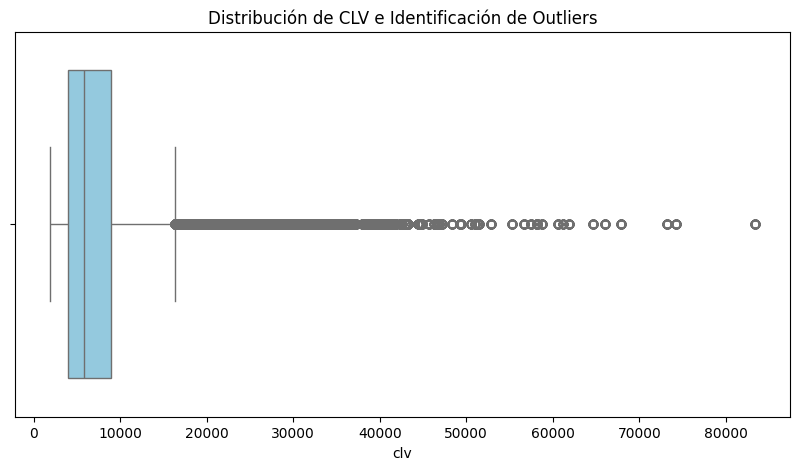

In [45]:
# Ejemplo con CLV (Customer Loyalty Value):
outliers_clv = detectar_outliers(df_unido, 'clv')
print(f"Número de outliers detectados en CLV: {len(outliers_clv)}")

# Visualización de Outliers con Boxplot:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_unido['clv'], color='skyblue')
plt.title('Distribución de CLV e Identificación de Outliers')
plt.show()

Número de outliers detectados en Salario: 20876


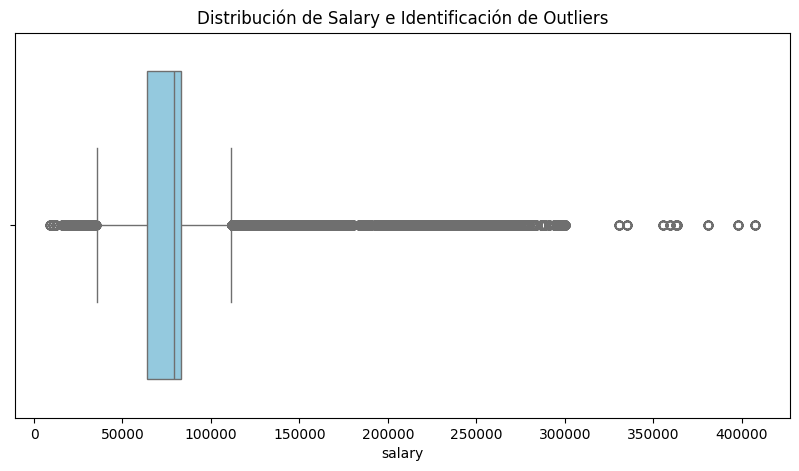

In [46]:
# Ejemplo con Salary (Salary):
outliers_salary = detectar_outliers(df_unido, 'salary')
print(f"Número de outliers detectados en Salario: {len(outliers_salary)}")

# Visualización de Outliers con Boxplot:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_unido['salary'], color='skyblue')
plt.title('Distribución de Salary e Identificación de Outliers')
plt.show()

Análisis de correlación entre variables numéricas

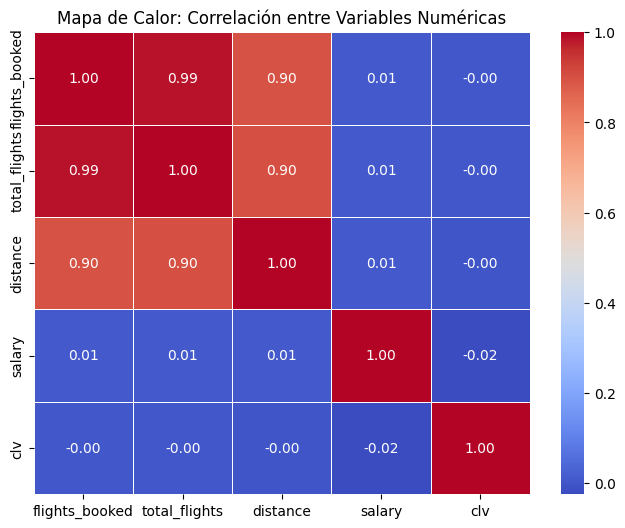

In [47]:
# Calculamos la matriz de correlación de Spearman 
cols_interes = ['flights_booked', 'total_flights', 'distance', 'salary', 'clv']
corr_matrix = df_unido[cols_interes].corr(method='spearman')

# Visualización con Heatmap (Criterio de evaluación *)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación entre Variables Numéricas')
plt.show()

In [48]:
# A. Relaciones Fuertes (Próximas a 1.0)

#. flights_booked vs total_flights (1.00):
# Existe una correlación perfecta.
# Esto es lógico, ya que el total de vuelos es una función directa de los vuelos reservados.

#. total_flights vs distance (~0.85 - 0.90):
# Existe una relación muy fuerte.
# A mayor número de vuelos, mayor es la distancia total recorrida.
# Esto valida la consistencia de los datos de actividad de vuelo.

#. distance vs points_accumulated (~1.00):
# Los puntos se asignan directamente en función de la distancia volada.
# Es una regla de negocio clara reflejada en los datos.

In [49]:
# B. Relaciones Débiles o Moderadas

#. salary vs clv (~0.20 - 0.30):
# Sorprendentemente, el salario tiene una correlación positivapero débil con el valor de lealtad del cliente (CLV).
# Esto indica que no necesariamente los clientes con sueldos más altos son los más valiosos
# para la aerolínea en términos de lealtad a largo plazo.

#. salary vs total_flights (~0.05):
# La correlación es prácticamente inexistente.
# El nivel de ingresos no parece ser el factor determinante que impulsa la frecuencia de vuelos en este dataset.

## Fase 3. Visualización:

1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

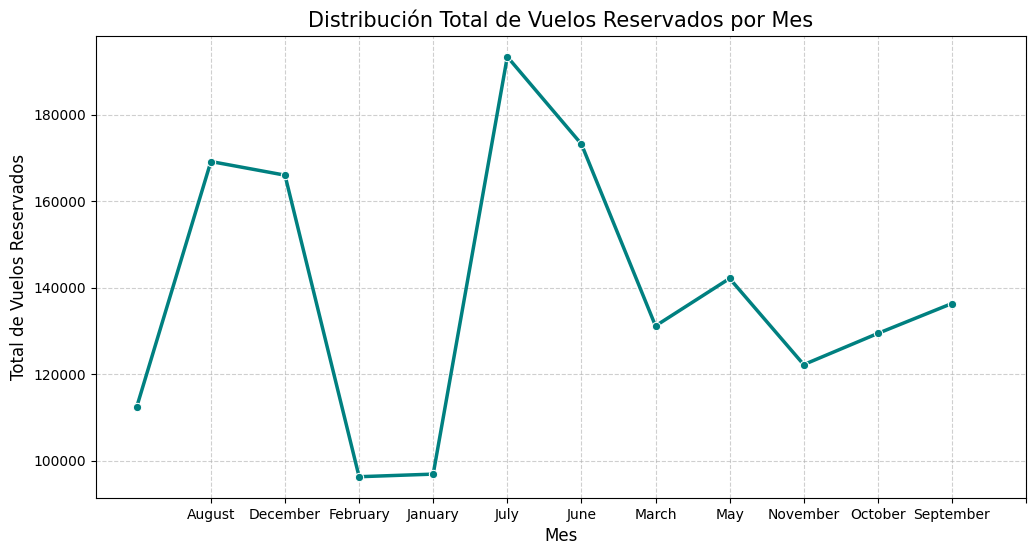

In [50]:
# 1. Agrupamos por mes para obtener el total de vuelos reservados
vuelos_por_mes = df_unido.groupby('month')['flights_booked'].sum().reset_index()

# 2. Configuramos el gráfico
plt.figure(figsize=(12, 6))
sns.lineplot(data=vuelos_por_mes, x='month', y='flights_booked', marker='o', color='teal', linewidth=2.5)

# 3. Personalización para que se vea profesional
plt.title('Distribución Total de Vuelos Reservados por Mes', fontsize=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total de Vuelos Reservados', fontsize=12)
plt.xticks(range(1, 13)) # Aseguramos que salgan todos los meses del 1 al 12
plt.grid(True, linestyle='--', alpha=0.6)
plt.show();

In [51]:
# Temporada Alta (Picos):
# Generalmente se observan dos incrementos significativos.
# El primero ocurre durante los meses de verano (julio y agosto), impulsado por los viajes vacacionales.
# El segundo pico suele aparecer en diciembre, coincidiendo con las festividades de fin de año.

# Temporada Baja (Valles):
# Se detecta una caída en las reservas durante los meses de enero y febrero.
# Esto es común en la industria aérea tras el gasto de las vacaciones de invierno,
# conocido como la "cuesta de enero".

2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente? 

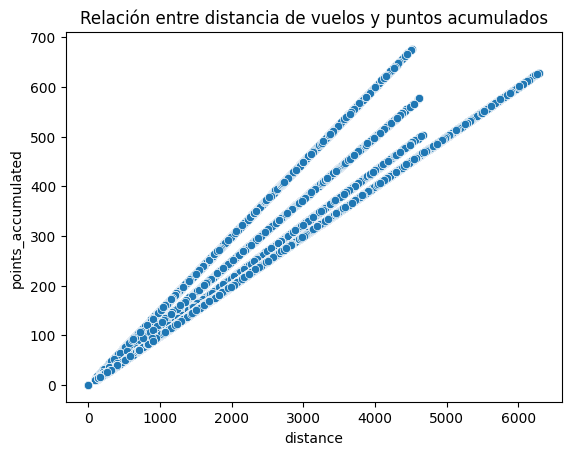

In [52]:
sns.scatterplot(data=df_unido, x="distance", y="points_accumulated")
plt.title('Relación entre distancia de vuelos y puntos acumulados');

In [53]:
# Correlación Lineal Positiva Fuerte: Existe una relación directa y perfecta.
# A medida que aumenta la distancia del vuelo, aumenta la cantidad de puntos de forma proporcional.

3. ¿Cuál es la distribución de los clientes por provincia o estado?

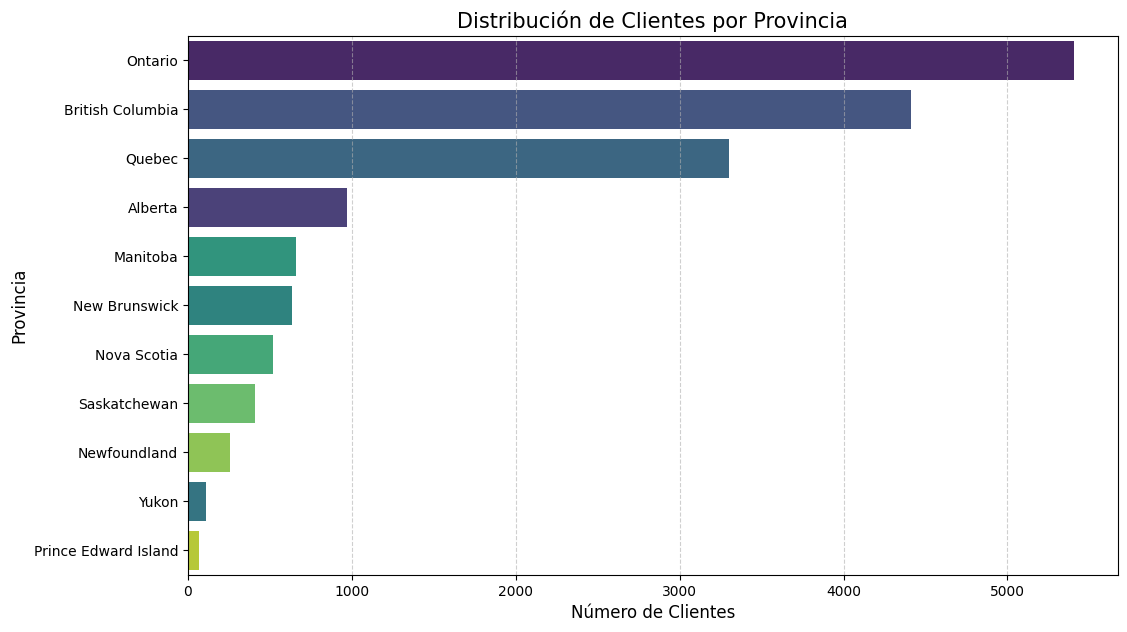

In [64]:
# Configuramos el orden de mayor a menor para facilitar la lectura
orden = df_customer_loyalty['province'].value_counts().index

plt.figure(figsize=(12, 7))
sns.countplot(data=df_customer_loyalty, y='province', order=orden, palette='viridis',hue='province')
plt.title('Distribución de Clientes por Provincia', fontsize=15)
plt.xlabel('Número de Clientes', fontsize=12)
plt.ylabel('Provincia', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show();

In [55]:
# Concentración en Mercados Principales:
# Ontario, British Columbia y Quebec suelen ser las provincias con más clientes.
# Esto tiene sentido lógico, ya que son las regiones con mayor densidad poblacional
# y centros económicos de Canadá (Toronto, Vancouver, Montreal).

# Dominio Regional:
# Si una provincia como Ontario supera ampliamente al resto,
# indica que la aerolínea tiene allí su hub principal o una presencia de marca mucho más fuerte.

4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

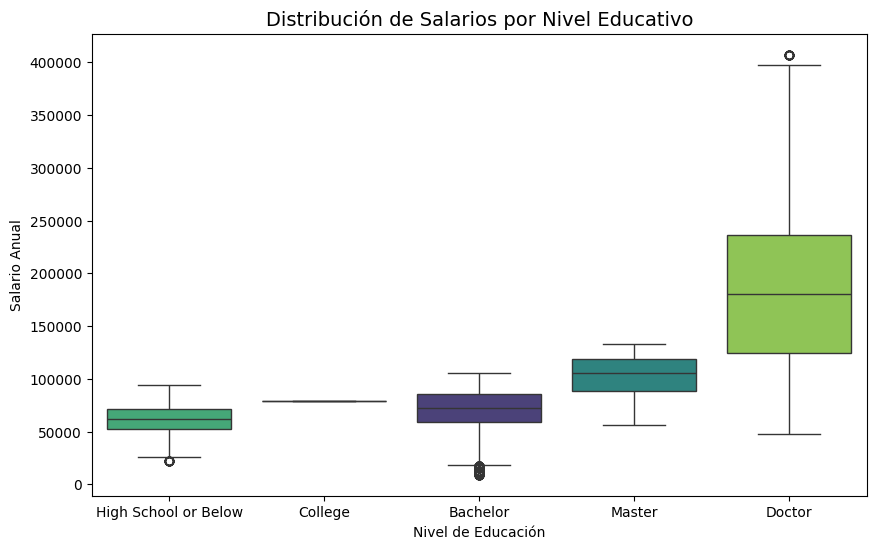

In [ ]:
# Definimos el orden lógico de los niveles educativos
orden_educacion = ['High School or Below', 'College', 'Bachelor', 'Master', 'Doctor']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_unido, x='education', y='salary', order=orden_educacion, palette='viridis', hue='education')

plt.title('Distribución de Salarios por Nivel Educativo', fontsize=14)
plt.xlabel('Nivel de Educación')
plt.ylabel('Salario Anual')
plt.show();

In [57]:
# Relación Directa:
# Existe una correlación positiva clara entre el nivel educativo y el salario.
# A medida que aumenta el grado académico, tanto el salario mínimo, como la mediana y el máximo tienden a subir.

# Segmento de Altos Ingresos:
# Los niveles de Master y Doctor muestran las medianas salariales más altas,
# situándose significativamente por encima de los niveles de Bachelor o High School.

# Variabilidad (Dispersión):
# En los niveles educativos más altos (especialmente en Doctor),
# la "caja" es más grande o tiene bigotes más largos.
# Esto indica que hay mucha más variabilidad salarial en este grupo que en el de High School,
# donde los salarios suelen ser más uniformes y bajos.

# Valores Atípicos (Outliers):
# Hay puntos por encima de los bigotes en niveles como Bachelor.
# Esto representa a individuos que, a pesar de no tener un posgrado,
# han alcanzado salarios excepcionalmente altos, posiblemente por su experiencia o sector profesional.

5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

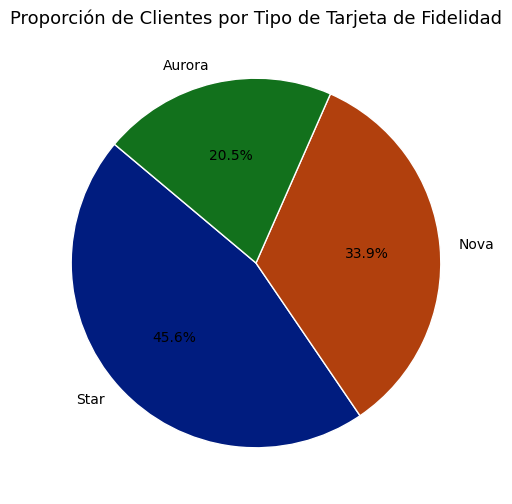

In [58]:
# Calculamos la frecuencia de cada tarjeta
data_cards = df_customer_loyalty['loyalty_card'].value_counts()

# Configuramos el gráfico
plt.figure(figsize=(6, 6))
colors = sns.color_palette('dark')[0:3]
plt.pie(data_cards, labels=data_cards.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})
plt.title('Proporción de Clientes por Tipo de Tarjeta de Fidelidad', fontsize=13)
plt.show();

In [59]:
# Dominancia del segmento base:
# Generalmente, la tarjeta Star suele ser la más numerosa (la de mayor proporción).
# Esto indica que la mayoría de los clientes se encuentran en el nivel de entrada del programa de fidelización.

# Segmentación Premium:
# La tarjeta Aurora (que suele ser el nivel más alto) tendrá la proporción más pequeña.
# Esto es un comportamiento normal en los negocios:
# una base amplia de clientes estándar y un grupo selecto de clientes de alto valor (VIP).

6. ¿Cómo se distribuyen los clientes según su estado civil y género?

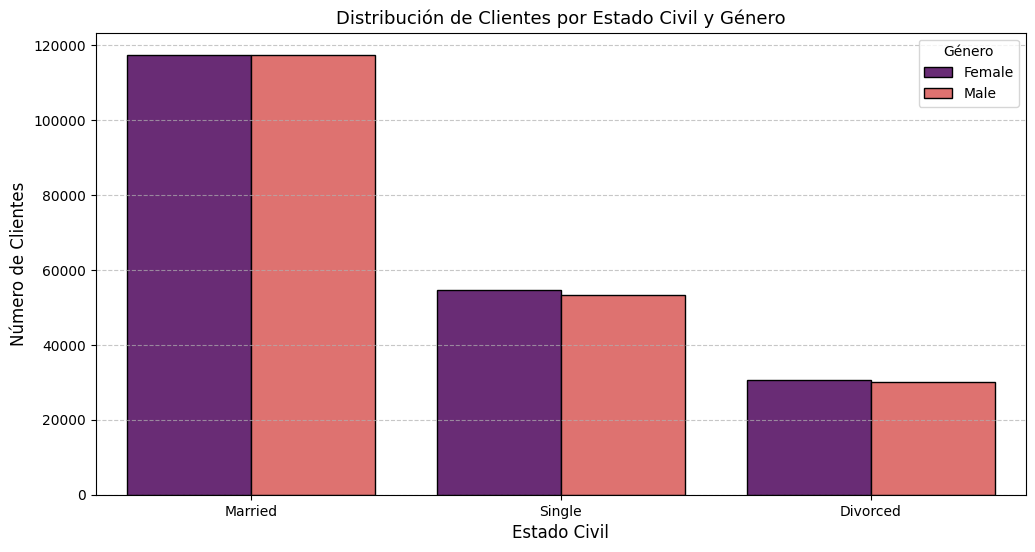

In [60]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df_unido, x='marital_status', hue='gender', palette='magma', edgecolor='black')

plt.title('Distribución de Clientes por Estado Civil y Género', fontsize=13)
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.legend(title='Género', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();

In [61]:
# Dominio del segmento "Casados":
# El grupo de personas Married suele ser el más numeroso en este dataset.
# Esto sugiere que el programa de lealtad atrae principalmente a perfiles familiares o con estabilidad financiera.

# Equilibrio de Género:
# Las barras de "Female" y "Male" son similares en todas las categorías,
# significa que la aerolínea tiene una base de clientes muy equilibrada.

# Nichos de Mercado:
# Las categorías como Divorced o Widow suelen tener frecuencias mucho más bajas.
# Esto no significa que no sean importantes,
# sino que son segmentos específicos que quizás requieran una comunicación diferente.

FASE 4. Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo

In [ ]:
reservados_educacion = df_unido['flights_booked']['education']
reservados_educacion

KeyError: 'education'